# Graph Neural Networks

In [ ]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [3]:
import json
import joblib
import libpysal
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import seaborn as sns
from IPython.display import display
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
import torch

# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

SEED = 42

In [ ]:
#| output: false

# Load processed data, scalers, and artifacts
processed_dir = Path("../data/processed")
artifacts_dir = Path("../data/artifacts")
geo_df = gpd.read_file("../data/processed/svi_counties.gpkg", layer="counties")

data = np.load(processed_dir / "svi_processed_splits.npz")

Xlog_train_scaled = data["Xlog_train_scaled"]
Xlog_val_scaled = data["Xlog_val_scaled"]
Xlog_test_scaled = data["Xlog_test_scaled"]

y_train_scaled = data["y_train_scaled"]
y_val_scaled = data["y_val_scaled"]
y_test_scaled = data["y_test_scaled"]

scaler_Xlog = joblib.load(processed_dir / "scaler_Xlog.pkl")
scaler_y = joblib.load(processed_dir / "scaler_y.pkl")

with open(artifacts_dir / "best_mlp_config.json", "r") as f:
    best_mlp_config = json.load(f)

config_df = pd.json_normalize(best_mlp_config).T
config_df.columns = ["Value"]

display(config_df)

,Value
feature_pipeline,log-transformed EP_*
architecture.model,MLP
architecture.variant,Deep-256
architecture.input_dim,16
architecture.hidden_layers,"[256, 128, 64, 32]"
architecture.activation,ReLU
architecture.dropout,0.0
regularization.weight_decay,0.001
training.optimizer,Adam
training.learning_rate,0.001


In [ ]:
#| output: false

# Use only CONUS counties
conus = geo_df[
    ~geo_df["FIPS"].str.startswith(("02","15","60","66","69","72","78"))
].copy()

# Build Queen contiguity weights
w_queen_conus = libpysal.weights.Queen.from_dataframe(conus, use_index=True)

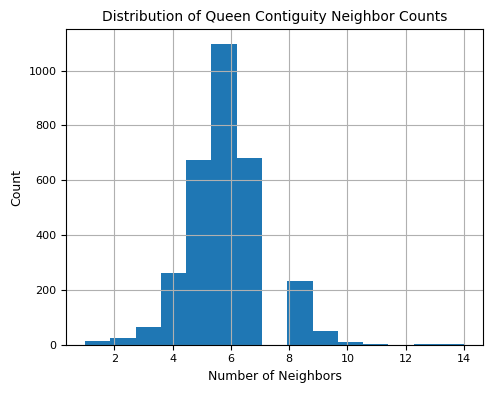

In [ ]:
#| label: tbl-queen-adj
#| tbl-cap: "Sparse adjacency matrix derived from Queen contiguity spatial weights."
#| output: false

W = w_queen.sparse

neighbor_counts = pd.Series(w_queen.cardinalities)

plt.figure(figsize=(5,4))

neighbor_counts.hist(bins=15)

plt.xlabel("Number of Neighbors")
plt.ylabel("Count")
plt.title("Distribution of Queen Contiguity Neighbor Counts")

plt.tight_layout()
plt.show()

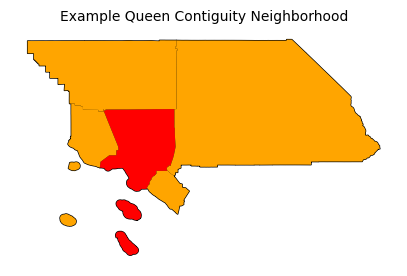

In [ ]:
#| output: false

# choose a county index
idx = conus[conus["FIPS"] == "06037"].index[0]  # Los Angeles

neighbors = w_queen.neighbors[idx]

fig, ax = plt.subplots(figsize=(5,5))

subset = conus.loc[[idx] + neighbors]

subset.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black"
)

conus.loc[[idx]].plot(ax=ax, color="red")
conus.loc[neighbors].plot(ax=ax, color="orange")

ax.set_title("Example Queen Contiguity Neighborhood")
ax.axis("off")

plt.show()